## CIT651: Introduction to Machine Learning — Assignment 2

##### *Datasets: heteroscedastic.csv · monotonic.csv · titanic.csv · CIFAR-10 · heart.csv*

In [ ]:
! wget -nc https://raw.githubusercontent.com/essawey/Assignment-2/refs/heads/main/heart.csv
! wget -nc https://raw.githubusercontent.com/essawey/Assignment-2/refs/heads/main/heteroscedastic.csv
! wget -nc https://raw.githubusercontent.com/essawey/Assignment-2/refs/heads/main/monotonic.csv
! wget -nc https://raw.githubusercontent.com/essawey/Assignment-2/refs/heads/main/titanic.csv

File ‘heart.csv’ already there; not retrieving.

File ‘heteroscedastic.csv’ already there; not retrieving.

File ‘monotonic.csv’ already there; not retrieving.

File ‘titanic.csv’ already there; not retrieving.



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datasets import load_dataset


from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.metrics import (mean_squared_error, r2_score, accuracy_score,
                             precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.feature_selection import f_classif

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True

---
# Part 1: Polynomial Regression, Regularization, and Model Analysis
> **Datasets:** `heteroscedastic.csv` and `monotonic.csv` — 35 points total (5 pts each)

## 0. Data Loading

In [ ]:
df_hetero = pd.read_csv('heteroscedastic.csv')
df_mono   = pd.read_csv('monotonic.csv')

print("Heteroscedastic Dataset — shape:", df_hetero.shape)
display(df_hetero.head())
print("\nMonotonic Dataset — shape:", df_mono.shape)
display(df_mono.head())

Heteroscedastic Dataset — shape: (300, 2)


,x,y
0,0.000000,-5.006572
1,0.334448,-4.650530
2,0.668896,-0.926905
3,1.003344,3.590906
4,1.337793,-0.092592



Monotonic Dataset — shape: (300, 2)


,x,y
0,0.000000,-5.503286
1,0.334448,-3.831045
2,0.668896,-2.158804
3,1.003344,-0.486563
4,1.337793,1.185677


## 1. Exploratory Data Analysis (EDA)

#### 1a. Missing Values, Outliers, and Feature Distributions

In [ ]:
for name, df in [("Heteroscedastic", df_hetero), ("Monotonic", df_mono)]:
    print(f"\n{'='*55}\n{name} Dataset\n{'='*55}")
    display(df.describe().round(4))
    print(f"Missing values:\n{df.isnull().sum()}")
    for col in ['x', 'y']:
        Q1, Q3 = df[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        n_out = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
        print(f"  IQR outliers in '{col}': {n_out}")


Heteroscedastic Dataset


,x,y
count,300.0000,300.0000
mean,50.0000,245.4302
std,29.0123,158.8379
min,0.0000,-5.0066
25%,25.0000,117.1945
50%,50.0000,238.4042
75%,75.0000,357.0311
max,100.0000,675.7850


Missing values:
x    0
y    0
dtype: int64
  IQR outliers in 'x': 0
  IQR outliers in 'y': 0

Monotonic Dataset


,x,y
count,300.0000,300.0000
mean,50.0000,244.4967
std,29.0123,145.0615
min,0.0000,-5.5033
25%,25.0000,119.4967
50%,50.0000,244.4967
75%,75.0000,369.4967
max,100.0000,494.4967


Missing values:
x    0
y    0
dtype: int64
  IQR outliers in 'x': 0
  IQR outliers in 'y': 0


#### 1b. Visualizations — Scatter Plots, Histograms, Box Plots

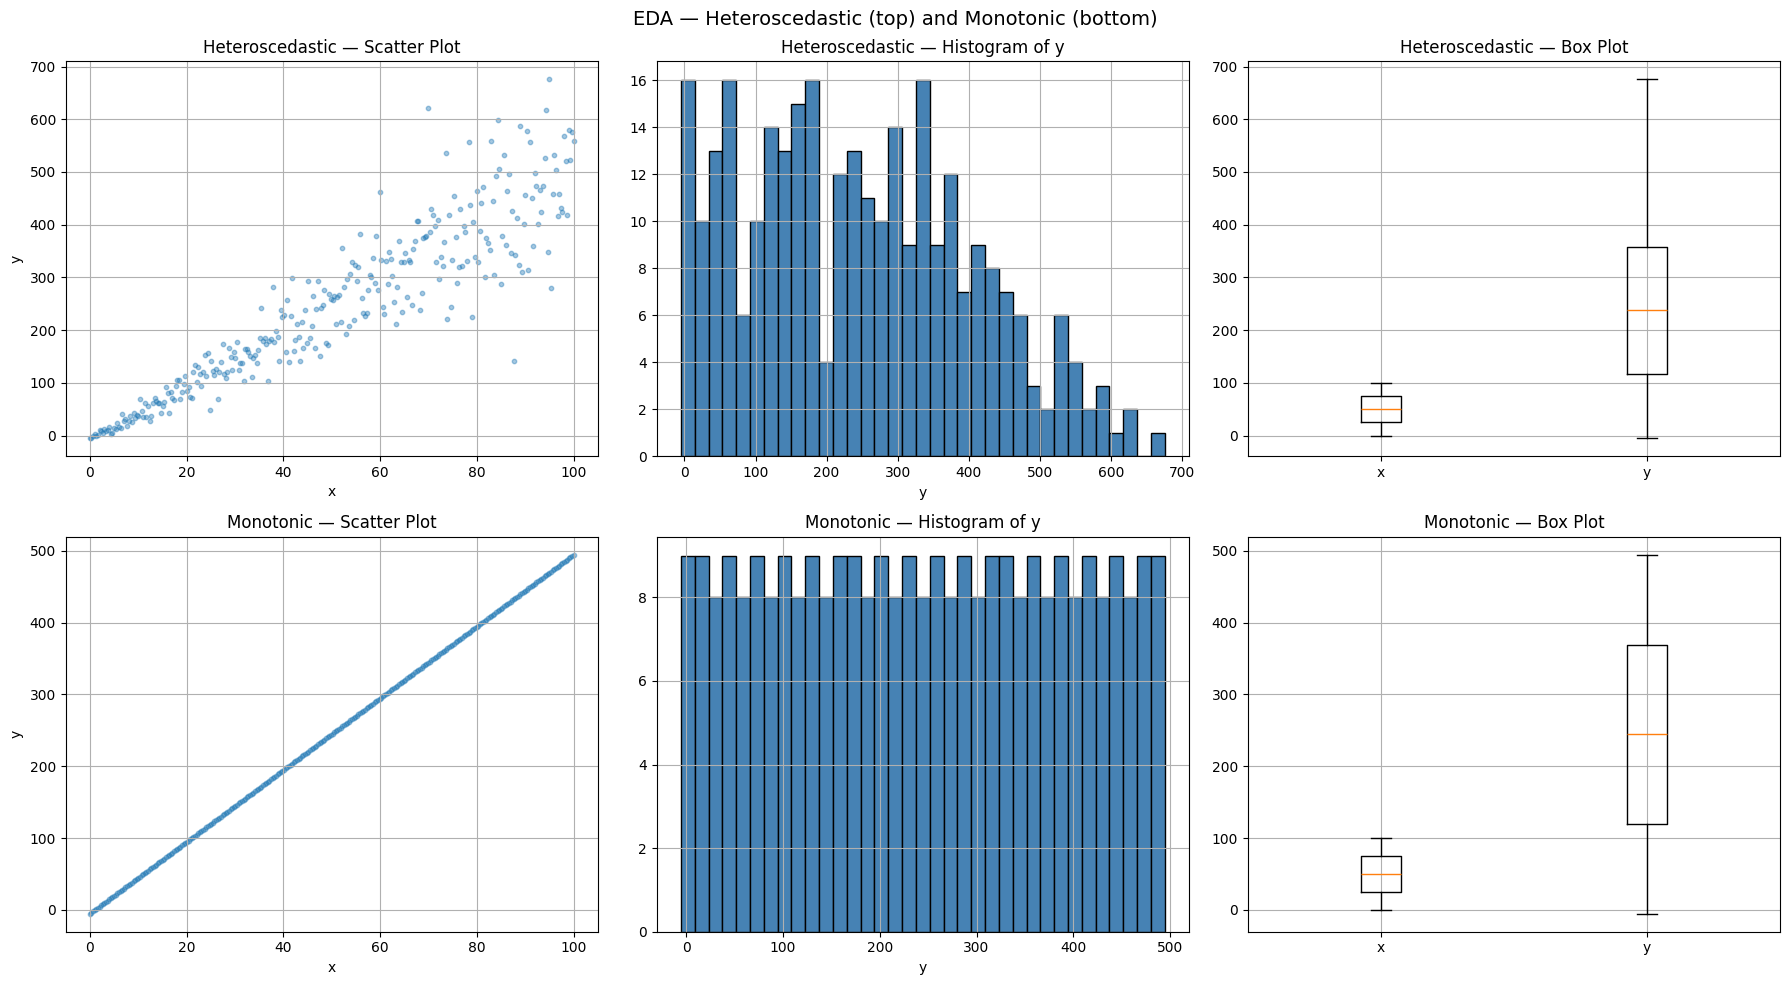

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("EDA — Heteroscedastic (top) and Monotonic (bottom)", fontsize=14)

for row, (name, df) in enumerate([("Heteroscedastic", df_hetero), ("Monotonic", df_mono)]):
    axes[row, 0].scatter(df['x'], df['y'], alpha=0.4, s=10)
    axes[row, 0].set_title(f'{name} — Scatter Plot')
    axes[row, 0].set_xlabel('x'); axes[row, 0].set_ylabel('y')

    axes[row, 1].hist(df['y'], bins=35, edgecolor='black', color='steelblue')
    axes[row, 1].set_title(f'{name} — Histogram of y')
    axes[row, 1].set_xlabel('y')

    axes[row, 2].boxplot([df['x'], df['y']], labels=['x', 'y'])
    axes[row, 2].set_title(f'{name} — Box Plot')

plt.tight_layout(); plt.show()

#### 1c. Data Preprocessing
> Apply appropriate techniques based on EDA findings (scaling, outlier handling, etc.)

In [ ]:
X_h = df_hetero[['x']].values;  y_h = df_hetero['y'].values
X_m = df_mono[['x']].values;    y_m = df_mono['y'].values

X_h_train, X_h_test, y_h_train, y_h_test = train_test_split(
    X_h, y_h, test_size=0.2, random_state=RANDOM_STATE)
X_m_train, X_m_test, y_m_train, y_m_test = train_test_split(
    X_m, y_m, test_size=0.2, random_state=RANDOM_STATE)

# Shared lookup used by all Part-1 sections
datasets_info = {
    "Heteroscedastic": (X_h_train, y_h_train, X_h_test, y_h_test),
    "Monotonic":       (X_m_train, y_m_train, X_m_test, y_m_test),
}

print(f"Heteroscedastic — Train: {X_h_train.shape}, Test: {X_h_test.shape}")
print(f"Monotonic       — Train: {X_m_train.shape}, Test: {X_m_test.shape}")
print("Note: StandardScaler is applied inside each pipeline, not here.")

Heteroscedastic — Train: (240, 1), Test: (60, 1)
Monotonic       — Train: (240, 1), Test: (60, 1)
Note: StandardScaler is applied inside each pipeline, not here.


## 2. Polynomial Regression — Basic Implementation

#### 2a. Polynomial Regression — Degrees 3 and 4 (No Regularization)

In [ ]:
def make_poly_pipeline(degree, regressor=None):
    return Pipeline([
        ('poly',   PolynomialFeatures(degree=degree, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model',  regressor if regressor is not None else LinearRegression()),
    ])

results_poly = {}
for name, (X_tr, y_tr, X_te, y_te) in datasets_info.items():
    results_poly[name] = {}
    for deg in [3, 4]:
        pipe = make_poly_pipeline(deg)
        pipe.fit(X_tr, y_tr)
        results_poly[name][deg] = pipe
        print(f"{name} | Degree {deg} — fitted")

Heteroscedastic | Degree 3 — fitted
Heteroscedastic | Degree 4 — fitted
Monotonic | Degree 3 — fitted
Monotonic | Degree 4 — fitted


#### 2b. Performance Evaluation — RMSE and R² on Train and Test Sets

$$
\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}
\qquad
R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}
$$

In [ ]:
def evaluate(model, X_tr, y_tr, X_te, y_te):
    return {
        'RMSE_train': round(np.sqrt(mean_squared_error(y_tr, model.predict(X_tr))), 4),
        'RMSE_test':  round(np.sqrt(mean_squared_error(y_te, model.predict(X_te))), 4),
        'R2_train':   round(r2_score(y_tr, model.predict(X_tr)), 4),
        'R2_test':    round(r2_score(y_te, model.predict(X_te)), 4),
    }

rows = []
for name, (X_tr, y_tr, X_te, y_te) in datasets_info.items():
    for deg in [3, 4]:
        m = evaluate(results_poly[name][deg], X_tr, y_tr, X_te, y_te)
        rows.append({"Dataset": name, "Degree": deg, **m})

df_poly_metrics = pd.DataFrame(rows)
display(df_poly_metrics)

,Dataset,Degree,RMSE_train,RMSE_test,R2_train,R2_test
0,Heteroscedastic,3,62.6479,52.0973,0.8436,0.8927
1,Heteroscedastic,4,62.4351,52.6105,0.8446,0.8905
2,Monotonic,3,0.0000,0.0000,1.0000,1.0000
3,Monotonic,4,0.0000,0.0000,1.0000,1.0000


#### 2c. Overfitting Analysis — Regression Curves and Metric Comparison

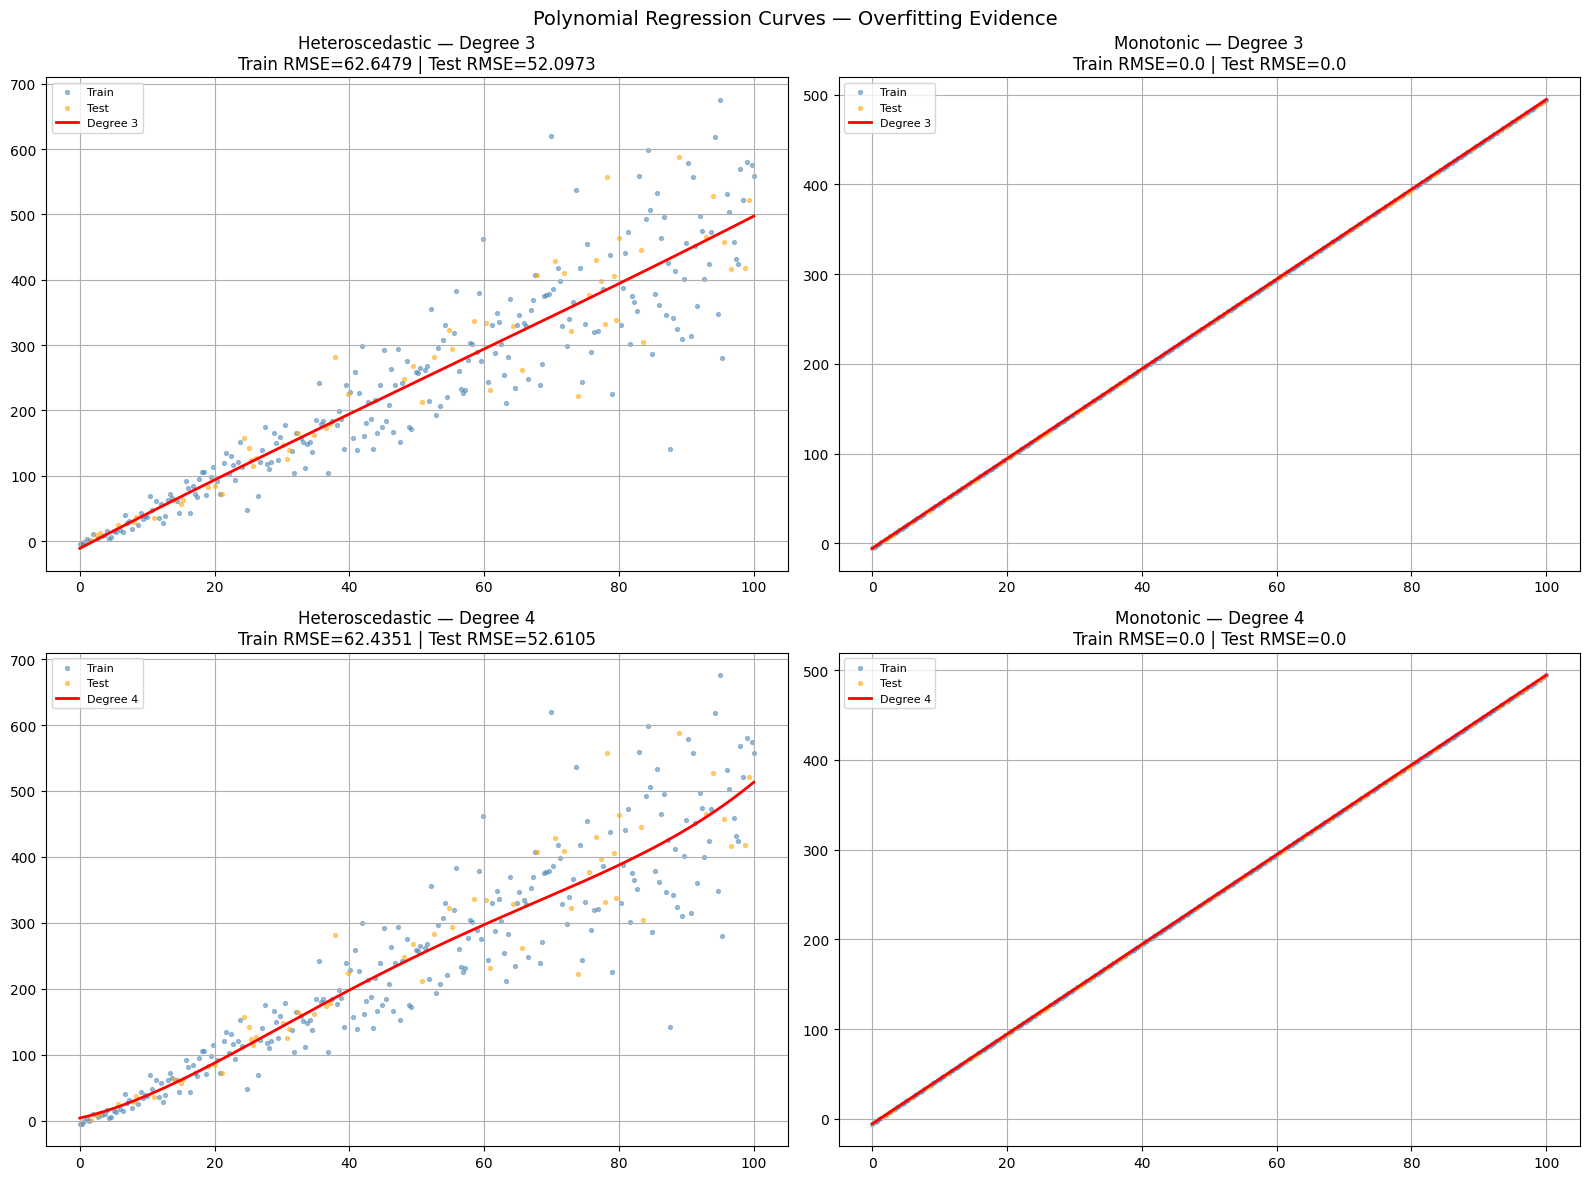


Overfitting: large gap between Train RMSE and Test RMSE.


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Polynomial Regression Curves — Overfitting Evidence", fontsize=14)

for col, (name, (X_tr, y_tr, X_te, y_te)) in enumerate(datasets_info.items()):
    x_line = np.linspace(min(X_tr.min(), X_te.min()),
                         max(X_tr.max(), X_te.max()), 300).reshape(-1, 1)
    for row, deg in enumerate([3, 4]):
        ax = axes[row, col]
        model = results_poly[name][deg]
        m = evaluate(model, X_tr, y_tr, X_te, y_te)
        ax.scatter(X_tr, y_tr, s=8, alpha=0.5, label='Train', color='steelblue')
        ax.scatter(X_te, y_te, s=8, alpha=0.5, label='Test',  color='orange')
        ax.plot(x_line, model.predict(x_line), color='red', lw=2, label=f'Degree {deg}')
        ax.set_title(f'{name} — Degree {deg}\n'
                     f'Train RMSE={m["RMSE_train"]} | Test RMSE={m["RMSE_test"]}')
        ax.legend(fontsize=8)

plt.tight_layout(); plt.show()
print("\nOverfitting: large gap between Train RMSE and Test RMSE.")

## 3. Advanced Regularization Techniques

| Regularization | Penalty | Effect |
| :--- | :---: | :--- |
| **Lasso (L1)** | $\alpha \sum |w_i|$ | Sparse solutions — drives coefficients to zero |
| **Ridge (L2)** | $\alpha \sum w_i^2$ | Shrinks coefficients — handles multicollinearity |
| **Elastic Net** | $\alpha_1 \sum |w_i| + \alpha_2 \sum w_i^2$ | Combination of L1 and L2 |

#### 3a. Lasso (L1), Ridge (L2), and Elastic Net — Degrees 3 and 4

In [ ]:
alphas = [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
regularizers = [
    ("Lasso",      Lasso,      {'max_iter': 10000}),
    ("Ridge",      Ridge,      {}),
    ("ElasticNet", ElasticNet, {'max_iter': 10000, 'l1_ratio': 0.5}),
]

results_reg = {}
for name, (X_tr, y_tr, X_te, y_te) in datasets_info.items():
    results_reg[name] = {3: {}, 4: {}}
    for deg in [3, 4]:
        for reg_name, RegClass, kwargs in regularizers:
            best_rmse, best_alpha, best_model = np.inf, None, None
            for alpha in alphas:
                pipe = Pipeline([
                    ('poly',   PolynomialFeatures(degree=deg, include_bias=False)),
                    ('scaler', StandardScaler()),
                    ('reg',    RegClass(alpha=alpha, **kwargs)),
                ])
                pipe.fit(X_tr, y_tr)
                rmse = np.sqrt(mean_squared_error(y_te, pipe.predict(X_te)))
                if rmse < best_rmse:
                    best_rmse, best_alpha, best_model = rmse, alpha, pipe
            results_reg[name][deg][reg_name] = {'model': best_model, 'alpha': best_alpha}
            print(f"{name} | Degree {deg} | {reg_name:10s} — best α={best_alpha}")

Heteroscedastic | Degree 3 | Lasso      — best α=0.1
Heteroscedastic | Degree 3 | Ridge      — best α=0.1
Heteroscedastic | Degree 3 | ElasticNet — best α=0.001
Heteroscedastic | Degree 4 | Lasso      — best α=0.1
Heteroscedastic | Degree 4 | Ridge      — best α=1.0
Heteroscedastic | Degree 4 | ElasticNet — best α=0.001
Monotonic | Degree 3 | Lasso      — best α=0.0001
Monotonic | Degree 3 | Ridge      — best α=0.0001
Monotonic | Degree 3 | ElasticNet — best α=0.0001
Monotonic | Degree 4 | Lasso      — best α=0.0001
Monotonic | Degree 4 | Ridge      — best α=0.0001
Monotonic | Degree 4 | ElasticNet — best α=0.0001


#### 3b. Optimal Regularization Strength (α) for Each Model

In [ ]:
rows = []
for name, (X_tr, y_tr, X_te, y_te) in datasets_info.items():
    for deg in [3, 4]:
        for reg_name in ["Lasso", "Ridge", "ElasticNet"]:
            info = results_reg[name][deg][reg_name]
            m = evaluate(info['model'], X_tr, y_tr, X_te, y_te)
            rows.append({"Dataset": name, "Degree": deg,
                         "Regularizer": reg_name, "Best_alpha": info['alpha'], **m})

df_reg_metrics = pd.DataFrame(rows)
display(df_reg_metrics)

,Dataset,Degree,Regularizer,Best_alpha,RMSE_train,RMSE_test,R2_train,R2_test
0,Heteroscedastic,3,Lasso,0.1000,62.6556,52.0483,0.8435,0.8929
1,Heteroscedastic,3,Ridge,0.1000,62.6518,52.0580,0.8436,0.8928
2,Heteroscedastic,3,ElasticNet,0.0010,62.6532,52.0533,0.8436,0.8928
3,Heteroscedastic,4,Lasso,0.1000,62.6555,52.0538,0.8435,0.8928
4,Heteroscedastic,4,Ridge,1.0000,62.6975,52.1566,0.8433,0.8924
5,Heteroscedastic,4,ElasticNet,0.0010,62.5983,52.1735,0.8438,0.8923
6,Monotonic,3,Lasso,0.0001,0.0001,0.0001,1.0000,1.0000
7,Monotonic,3,Ridge,0.0001,0.0006,0.0006,1.0000,1.0000
8,Monotonic,3,ElasticNet,0.0001,0.0034,0.0033,1.0000,1.0000
9,Monotonic,4,Lasso,0.0001,0.0001,0.0001,1.0000,1.0000


#### 3c. Regularized vs. Unregularized — Performance Comparison

,Dataset,Degree,Model,RMSE_test,R2_test
0,Heteroscedastic,3,Lasso,52.0483,0.8929
1,Heteroscedastic,3,ElasticNet,52.0533,0.8928
2,Heteroscedastic,3,Ridge,52.0580,0.8928
3,Heteroscedastic,3,No Regularization,52.0973,0.8927
4,Heteroscedastic,4,Lasso,52.0538,0.8928
5,Heteroscedastic,4,Ridge,52.1566,0.8924
6,Heteroscedastic,4,ElasticNet,52.1735,0.8923
7,Heteroscedastic,4,No Regularization,52.6105,0.8905
8,Monotonic,3,No Regularization,0.0000,1.0000
9,Monotonic,3,Lasso,0.0001,1.0000


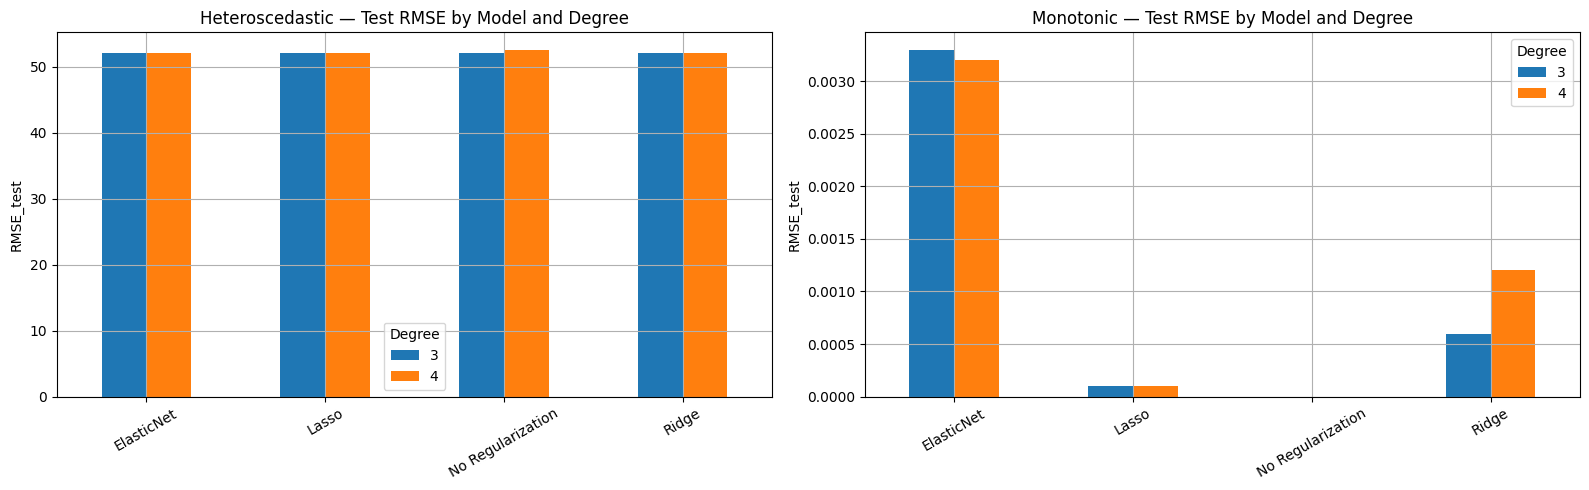

In [ ]:
compare_rows = []
for _, row in df_poly_metrics.iterrows():
    compare_rows.append({"Dataset": row["Dataset"], "Degree": int(row["Degree"]),
                         "Model": "No Regularization",
                         "RMSE_test": row["RMSE_test"], "R2_test": row["R2_test"]})
for _, row in df_reg_metrics.iterrows():
    compare_rows.append({"Dataset": row["Dataset"], "Degree": int(row["Degree"]),
                         "Model": row["Regularizer"],
                         "RMSE_test": row["RMSE_test"], "R2_test": row["R2_test"]})

df_compare = (pd.DataFrame(compare_rows)
              .sort_values(["Dataset", "Degree", "RMSE_test"])
              .reset_index(drop=True))
display(df_compare)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, (name, grp) in zip(axes, df_compare.groupby("Dataset")):
    grp.pivot(index="Model", columns="Degree", values="RMSE_test").plot(kind='bar', ax=ax)
    ax.set_title(f'{name} — Test RMSE by Model and Degree')
    ax.set_xlabel(''); ax.set_ylabel('RMSE_test')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

## 4. Model Optimization and Hyperparameter Tuning

#### 4a. Grid Search / Random Search — Optimal Degree and Regularization Strength

In [ ]:
param_grid = {
    'poly__degree': [2, 3, 4, 5],
    'reg__alpha':   [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0],
}

best_gs = {}
for name, (X_tr, y_tr, X_te, y_te) in datasets_info.items():
    pipe = Pipeline([
        ('poly',   PolynomialFeatures(include_bias=False)),
        ('scaler', StandardScaler()),
        ('reg',    Ridge()),
    ])
    gs = GridSearchCV(pipe, param_grid, cv=5,
                      scoring='neg_root_mean_squared_error', n_jobs=-1)
    gs.fit(X_tr, y_tr)
    best_gs[name] = gs
    print(f"{name}: best_params={gs.best_params_}  |  CV RMSE={-gs.best_score_:.4f}")

Heteroscedastic: best_params={'poly__degree': 2, 'reg__alpha': 1.0}  |  CV RMSE=63.7488
Monotonic: best_params={'poly__degree': 2, 'reg__alpha': 0.0001}  |  CV RMSE=0.0003


#### 4b. Optimized Model Evaluation and Comparison with Previous Models

In [ ]:
rows = []
for name, (X_tr, y_tr, X_te, y_te) in datasets_info.items():
    m = evaluate(best_gs[name].best_estimator_, X_tr, y_tr, X_te, y_te)
    rows.append({"Dataset": name, "Model": "Optimized (GridSearch)", **m})

df_opt = pd.DataFrame(rows)
display(df_opt)

# Compare optimized RMSE against best previous regularized RMSE
best_prev = (df_compare[df_compare['Model'] != 'No Regularization']
             .groupby('Dataset')['RMSE_test'].min()
             .reset_index()
             .rename(columns={'RMSE_test': 'Best_Regularized_RMSE'}))
merged = best_prev.merge(
    df_opt[['Dataset', 'RMSE_test']].rename(columns={'RMSE_test': 'Optimized_RMSE'}))
display(merged)

,Dataset,Model,RMSE_train,RMSE_test,R2_train,R2_test
0,Heteroscedastic,Optimized (GridSearch),62.6920,52.2768,0.8434,0.8919
1,Monotonic,Optimized (GridSearch),0.0002,0.0002,1.0000,1.0000


,Dataset,Best_Regularized_RMSE,Optimized_RMSE
0,Heteroscedastic,52.0483,52.2768
1,Monotonic,0.0001,0.0002


## 5. Handling Heteroscedasticity
> **Heteroscedastic dataset only**

#### 5a. Strategy Implementation
> Apply target variable transformation (e.g., log transform) or Weighted Least Squares (WLS)

Log-transformed model — RMSE: 61.3014  |  R²: 0.8514


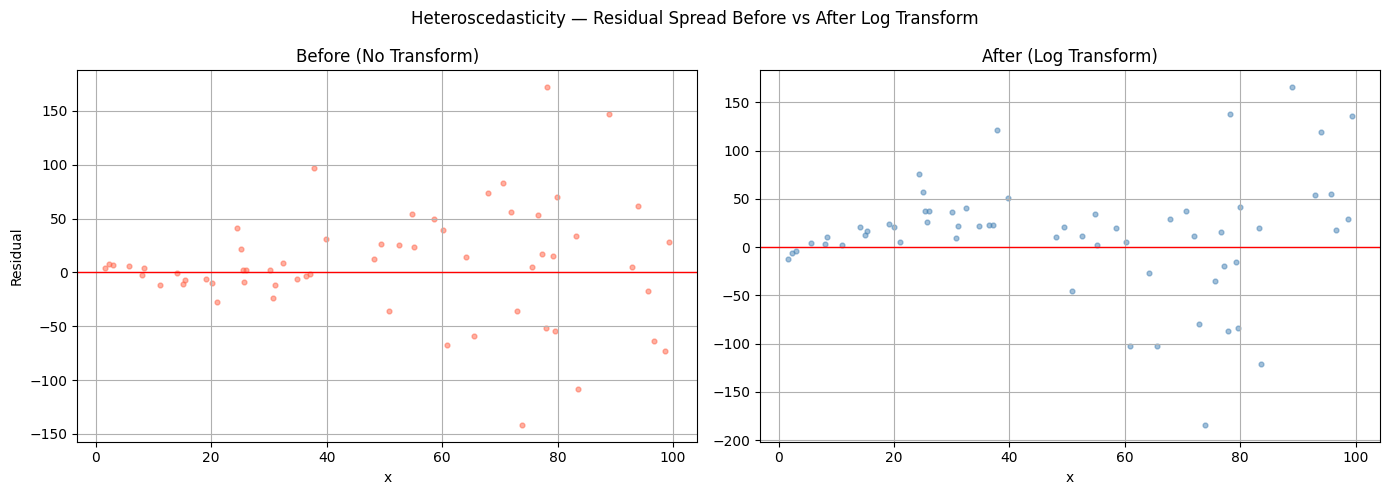

In [ ]:
# Strategy: log-transform y to stabilise the growing variance
shift = abs(df_hetero['y'].min()) + 1   # shift so all values > 0 before log

y_h_train_log = np.log(y_h_train + shift)
y_h_test_log  = np.log(y_h_test  + shift)

pipe_log = Pipeline([
    ('poly',   PolynomialFeatures(degree=3, include_bias=False)),
    ('scaler', StandardScaler()),
    ('reg',    Ridge(alpha=1.0)),
])
pipe_log.fit(X_h_train, y_h_train_log)

# Back-transform predictions to original scale
y_pred_log  = pipe_log.predict(X_h_test)
y_pred_orig = np.exp(y_pred_log) - shift

rmse_hetero_log = round(np.sqrt(mean_squared_error(y_h_test, y_pred_orig)), 4)
r2_hetero_log   = round(r2_score(y_h_test, y_pred_orig), 4)
print(f"Log-transformed model — RMSE: {rmse_hetero_log}  |  R²: {r2_hetero_log}")

# Residual plots: before vs after
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Heteroscedasticity — Residual Spread Before vs After Log Transform")

y_base = results_poly["Heteroscedastic"][3].predict(X_h_test)
axes[0].scatter(X_h_test, y_h_test - y_base, alpha=0.5, s=12, color='tomato')
axes[0].axhline(0, color='red', lw=1)
axes[0].set_title("Before (No Transform)"); axes[0].set_xlabel('x'); axes[0].set_ylabel('Residual')

axes[1].scatter(X_h_test, y_h_test - y_pred_orig, alpha=0.5, s=12, color='steelblue')
axes[1].axhline(0, color='red', lw=1)
axes[1].set_title("After (Log Transform)"); axes[1].set_xlabel('x')

plt.tight_layout(); plt.show()

#### 5b. Before vs. After — Performance Comparison

In [ ]:
m_before = evaluate(results_poly["Heteroscedastic"][3],
                    X_h_train, y_h_train, X_h_test, y_h_test)

print("Performance Comparison — Heteroscedastic Dataset")
print(f"\nBefore (Degree-3, No Transform):")
print(f"  RMSE_train : {m_before['RMSE_train']}  |  RMSE_test : {m_before['RMSE_test']}")
print(f"  R2_train   : {m_before['R2_train']}   |  R2_test   : {m_before['R2_test']}")
print(f"\nAfter (Degree-3, Log-Transform of y):")
print(f"  RMSE_test  : {rmse_hetero_log}")
print(f"  R2_test    : {r2_hetero_log}")

Performance Comparison — Heteroscedastic Dataset

Before (Degree-3, No Transform):
  RMSE_train : 62.6479  |  RMSE_test : 52.0973
  R2_train   : 0.8436   |  R2_test   : 0.8927

After (Degree-3, Log-Transform of y):
  RMSE_test  : 61.3014
  R2_test    : 0.8514


## 6. Error Analysis and Model Interpretation

#### 6a. Residual Analysis
> Investigate where and why the model makes errors — check for patterns in residuals

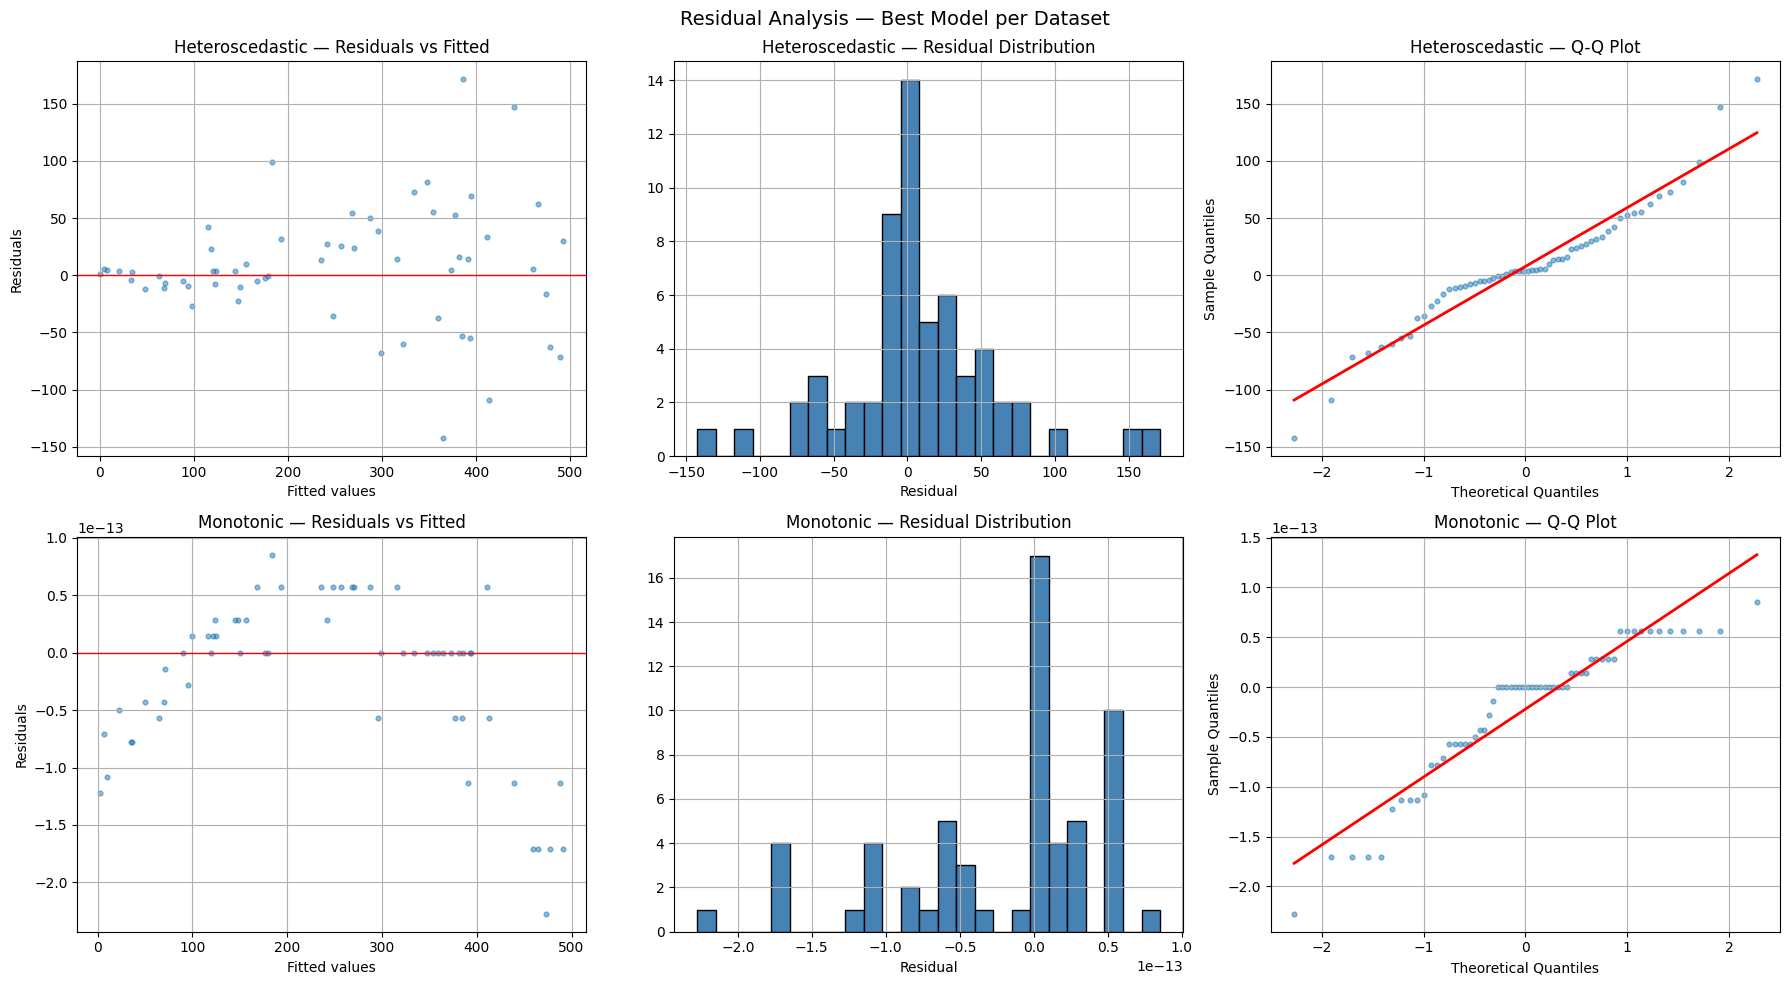

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Residual Analysis — Best Model per Dataset", fontsize=14)

for row, (name, (X_tr, y_tr, X_te, y_te)) in enumerate(datasets_info.items()):
    best_row = df_compare[df_compare['Dataset'] == name].sort_values('RMSE_test').iloc[0]
    deg, reg = int(best_row['Degree']), best_row['Model']
    model = (results_poly[name][deg] if reg == 'No Regularization'
             else results_reg[name][deg][reg]['model'])

    fitted    = model.predict(X_te)
    residuals = y_te - fitted

    # Residuals vs Fitted
    axes[row, 0].scatter(fitted, residuals, alpha=0.5, s=12)
    axes[row, 0].axhline(0, color='red', lw=1)
    axes[row, 0].set_title(f'{name} — Residuals vs Fitted')
    axes[row, 0].set_xlabel('Fitted values'); axes[row, 0].set_ylabel('Residuals')

    # Histogram
    axes[row, 1].hist(residuals, bins=25, edgecolor='black', color='steelblue')
    axes[row, 1].set_title(f'{name} — Residual Distribution')
    axes[row, 1].set_xlabel('Residual')

    # Q-Q plot
    (osm, osr), (slope, intercept, _) = stats.probplot(residuals, dist='norm')
    axes[row, 2].scatter(osm, osr, alpha=0.5, s=12)
    axes[row, 2].plot(osm, slope * np.array(osm) + intercept, color='red', lw=2)
    axes[row, 2].set_title(f'{name} — Q-Q Plot')
    axes[row, 2].set_xlabel('Theoretical Quantiles')
    axes[row, 2].set_ylabel('Sample Quantiles')

plt.tight_layout(); plt.show()

#### 6b. Coefficient Interpretation
> Interpret model coefficients and discuss their implications in the context of each dataset

In [ ]:
for name, (X_tr, y_tr, X_te, y_te) in datasets_info.items():
    best_row = df_compare[df_compare['Dataset'] == name].sort_values('RMSE_test').iloc[0]
    deg, reg = int(best_row['Degree']), best_row['Model']
    model = (results_poly[name][deg] if reg == 'No Regularization'
             else results_reg[name][deg][reg]['model'])

    poly_step  = model.named_steps['poly']
    feat_names = poly_step.get_feature_names_out(['x'])
    estimator  = model[-1]  # last pipeline step

    coef_df = pd.DataFrame({'Feature': feat_names,
                            'Coefficient': estimator.coef_.round(4)})
    print(f"\n{'='*55}\n{name} — Best Model: {reg} (Degree {deg})\n{'='*55}")
    display(coef_df)
    print(f"Intercept: {estimator.intercept_:.4f}")
    print(f"\nInterpretation: positive coefficients indicate that higher-order x terms "
          f"push y upward; negative coefficients suppress it.")


Heteroscedastic — Best Model: Lasso (Degree 3)


,Feature,Coefficient
0,x,145.3873
1,x^2,0.0000
2,x^3,0.0000


Intercept: 243.5320

Interpretation: positive coefficients indicate that higher-order x terms push y upward; negative coefficients suppress it.

Monotonic — Best Model: No Regularization (Degree 3)


,Feature,Coefficient
0,x,144.3886
1,x^2,0.0000
2,x^3,0.0000


Intercept: 244.1414

Interpretation: positive coefficients indicate that higher-order x terms push y upward; negative coefficients suppress it.


---
# Part 2: Decision Trees and Random Forest
> **Dataset:** `titanic.csv` — Goal: predict passenger survival — 35 points total (5 pts each)

## 0. Data Loading and Preprocessing
> Handle missing values, encode categorical features (Sex, Embarked), scale numerical features, and split into training/validation sets

In [ ]:
df_titanic = pd.read_csv('titanic.csv')
print("Shape:", df_titanic.shape)
print("\nMissing values:"); display(df_titanic.isnull().sum()[df_titanic.isnull().sum() > 0])

# Drop low-signal / high-cardinality columns
df_titanic.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], inplace=True)

# Impute
df_titanic['Age'].fillna(df_titanic['Age'].median(), inplace=True)
df_titanic['Embarked'].fillna(df_titanic['Embarked'].mode()[0], inplace=True)

# Encode
df_titanic['Sex'] = (df_titanic['Sex'] == 'male').astype(int)
df_titanic = pd.get_dummies(df_titanic, columns=['Embarked'], drop_first=False)

X_titanic = df_titanic.drop(columns=['Survived']).values
y_titanic = df_titanic['Survived'].values

scaler_t = StandardScaler()
X_titanic_sc = scaler_t.fit_transform(X_titanic)

print(f"\nFinal feature shape : {X_titanic_sc.shape}")
print("Features:", df_titanic.drop(columns=['Survived']).columns.tolist())

Shape: (891, 12)

Missing values:


,0
Age,177
Cabin,687
Embarked,2



Final feature shape : (891, 9)
Features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_C', 'Embarked_Q', 'Embarked_S']


## Q1. Decision Tree Classifier — Unlimited Depth
> 80/20 split — average accuracy over 100 random splits

In [ ]:
N_SPLITS = 100
accs_unlimited = []

for seed in range(N_SPLITS):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_titanic_sc, y_titanic, test_size=0.2, random_state=seed)
    dt = DecisionTreeClassifier(random_state=seed)
    dt.fit(X_tr, y_tr)
    accs_unlimited.append(accuracy_score(y_te, dt.predict(X_te)))

avg_unlimited = np.mean(accs_unlimited)
print(f"Decision Tree — Unlimited Depth")
print(f"Average Accuracy over {N_SPLITS} splits : {avg_unlimited:.4f}")
print(f"Std Dev                               : {np.std(accs_unlimited):.4f}")

Decision Tree — Unlimited Depth
Average Accuracy over 100 splits : 0.7842
Std Dev                               : 0.0279


## Q2. Experiment with Depth Limits
> Vary `max_depth` from 1 to 10 — average over 100 random splits per depth — identify the best depth

In [ ]:
depth_val_accs = {}

for max_depth in range(1, 11):
    accs = []
    for seed in range(N_SPLITS):
        X_tr, X_te, y_tr, y_te = train_test_split(
            X_titanic_sc, y_titanic, test_size=0.2, random_state=seed)
        dt = DecisionTreeClassifier(max_depth=max_depth, random_state=seed)
        dt.fit(X_tr, y_tr)
        accs.append(accuracy_score(y_te, dt.predict(X_te)))
    depth_val_accs[max_depth] = np.mean(accs)
    print(f"Depth {max_depth:2d} — Avg Accuracy: {np.mean(accs):.4f}")

best_depth = max(depth_val_accs, key=depth_val_accs.get)
print(f"\nBest depth : {best_depth}  (accuracy = {depth_val_accs[best_depth]:.4f})")

Depth  1 — Avg Accuracy: 0.7876
Depth  2 — Avg Accuracy: 0.7760
Depth  3 — Avg Accuracy: 0.8148
Depth  4 — Avg Accuracy: 0.8116
Depth  5 — Avg Accuracy: 0.8109
Depth  6 — Avg Accuracy: 0.8128
Depth  7 — Avg Accuracy: 0.8145
Depth  8 — Avg Accuracy: 0.8092
Depth  9 — Avg Accuracy: 0.8063
Depth 10 — Avg Accuracy: 0.7995

Best depth : 3  (accuracy = 0.8148)


## Q3. Overfitting Analysis
> Plot accuracy vs. depth for both training and validation sets — analyze overfitting behavior

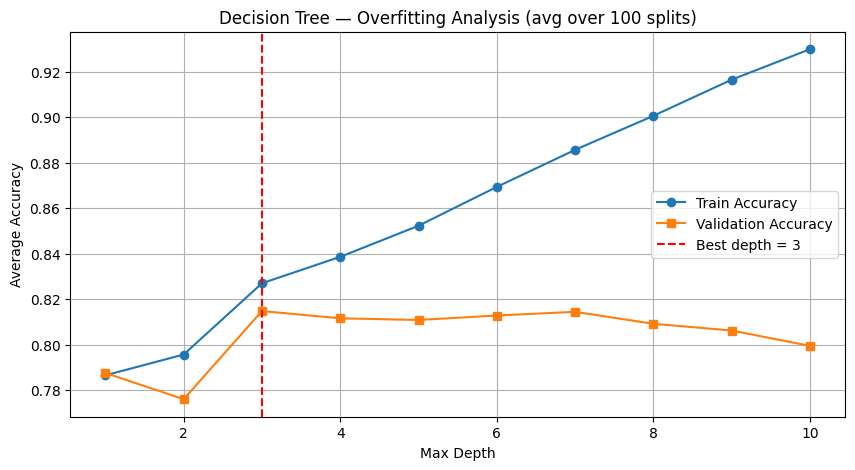

Overfitting: train accuracy rises monotonically while validation plateaus/drops after the optimal depth.


In [ ]:
dt_train_accs, dt_val_accs = [], []

for max_depth in range(1, 11):
    t_accs, v_accs = [], []
    for seed in range(N_SPLITS):
        X_tr, X_te, y_tr, y_te = train_test_split(
            X_titanic_sc, y_titanic, test_size=0.2, random_state=seed)
        dt = DecisionTreeClassifier(max_depth=max_depth, random_state=seed)
        dt.fit(X_tr, y_tr)
        t_accs.append(accuracy_score(y_tr, dt.predict(X_tr)))
        v_accs.append(accuracy_score(y_te, dt.predict(X_te)))
    dt_train_accs.append(np.mean(t_accs))
    dt_val_accs.append(np.mean(v_accs))

depths = list(range(1, 11))
plt.figure(figsize=(10, 5))
plt.plot(depths, dt_train_accs, marker='o', label='Train Accuracy')
plt.plot(depths, dt_val_accs,   marker='s', label='Validation Accuracy')
plt.axvline(best_depth, color='red', linestyle='--', label=f'Best depth = {best_depth}')
plt.xlabel('Max Depth'); plt.ylabel('Average Accuracy')
plt.title('Decision Tree — Overfitting Analysis (avg over 100 splits)')
plt.legend(); plt.show()

print("Overfitting: train accuracy rises monotonically while validation plateaus/drops after the optimal depth.")

## Q4. Impact of Training Data Size
> Vary training size from 5% to 90% in steps of 5% — full-depth trees — plot and describe the impact

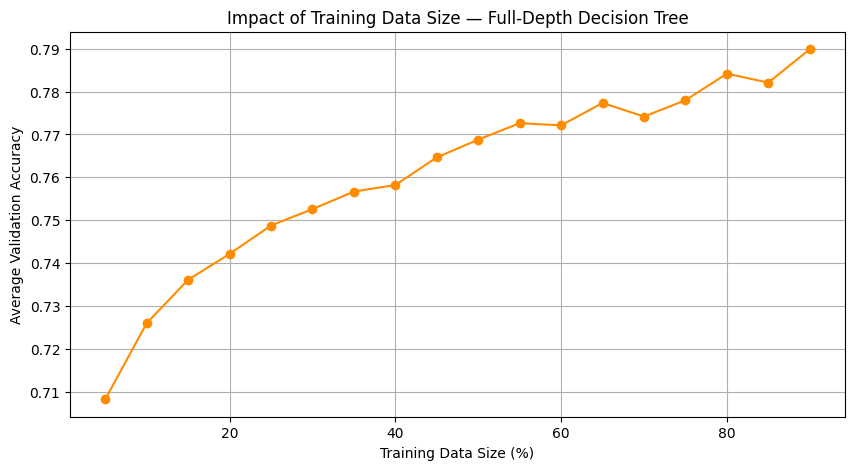

Accuracy generally increases with more training data, then plateaus as the model saturates.


In [ ]:
train_sizes = np.arange(0.05, 0.91, 0.05)
size_accs   = []

for size in train_sizes:
    accs = []
    for seed in range(N_SPLITS):
        X_tr, X_te, y_tr, y_te = train_test_split(
            X_titanic_sc, y_titanic, test_size=round(1 - size, 2), random_state=seed)
        dt = DecisionTreeClassifier(random_state=seed)  # full depth
        dt.fit(X_tr, y_tr)
        accs.append(accuracy_score(y_te, dt.predict(X_te)))
    size_accs.append(np.mean(accs))

plt.figure(figsize=(10, 5))
plt.plot(train_sizes * 100, size_accs, marker='o', color='darkorange')
plt.xlabel('Training Data Size (%)'); plt.ylabel('Average Validation Accuracy')
plt.title('Impact of Training Data Size — Full-Depth Decision Tree')
plt.show()

print("Accuracy generally increases with more training data, then plateaus as the model saturates.")

## Q5. Random Forest Classifier
> Same 80/20 split — compare with best Decision Tree — average over 100 random splits

In [ ]:
rf_accs = []

for seed in range(N_SPLITS):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_titanic_sc, y_titanic, test_size=0.2, random_state=seed)
    rf = RandomForestClassifier(n_estimators=100, random_state=seed, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    rf_accs.append(accuracy_score(y_te, rf.predict(X_te)))

avg_rf = np.mean(rf_accs)
print(f"Random Forest (100 trees)")
print(f"Average Accuracy over {N_SPLITS} splits : {avg_rf:.4f}")
print(f"Std Dev                               : {np.std(rf_accs):.4f}")
print(f"\nBest Decision Tree (depth={best_depth})  : {depth_val_accs[best_depth]:.4f}")
print(f"Improvement                           : {avg_rf - depth_val_accs[best_depth]:+.4f}")

Random Forest (100 trees)
Average Accuracy over 100 splits : 0.8093
Std Dev                               : 0.0274

Best Decision Tree (depth=3)  : 0.8148
Improvement                           : -0.0055


## Q6. Hyperparameter Tuning for Random Forest
> Experiment with `n_estimators` and `max_depth` — 5-fold cross-validation to find best combination

In [ ]:
X_tr_rf, X_te_rf, y_tr_rf, y_te_rf = train_test_split(
    X_titanic_sc, y_titanic, test_size=0.2, random_state=RANDOM_STATE)

param_grid_rf = {
    'n_estimators': [10, 50, 100, 200],
    'max_depth':    [None, 3, 5, 10],
}

gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
gs_rf.fit(X_tr_rf, y_tr_rf)

print(f"Best params    : {gs_rf.best_params_}")
print(f"Best CV acc    : {gs_rf.best_score_:.4f}")
print(f"Test accuracy  : {accuracy_score(y_te_rf, gs_rf.best_estimator_.predict(X_te_rf)):.4f}")

Best params    : {'max_depth': 5, 'n_estimators': 10}
Best CV acc    : 0.8300
Test accuracy  : 0.7989


## Q7. Visualize Random Forest Performance
> Plot validation accuracy vs. `n_estimators` — discuss overfitting/underfitting trends

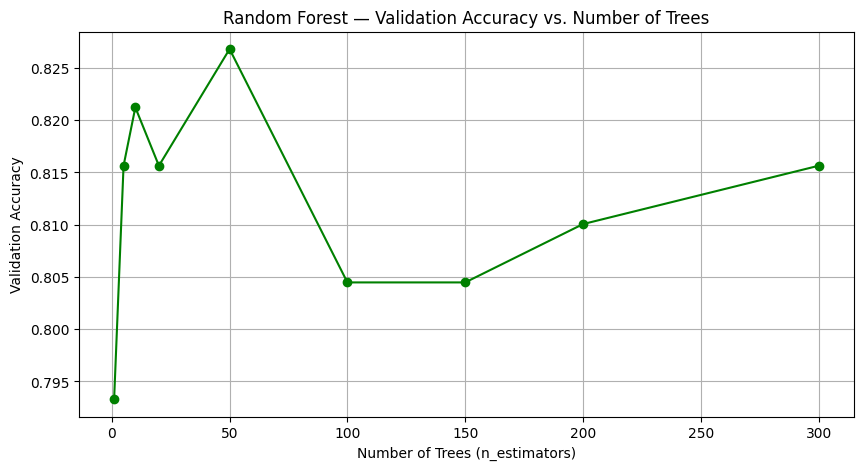

Best n_estimators: 50  (accuracy = 0.8268)
Accuracy stabilises as more trees are added; adding trees past the knee point yields marginal gains.


In [ ]:
n_est_list = [1, 5, 10, 20, 50, 100, 150, 200, 300]
rf_val_accs = []

for n_est in n_est_list:
    rf = RandomForestClassifier(n_estimators=n_est, random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(X_tr_rf, y_tr_rf)
    rf_val_accs.append(accuracy_score(y_te_rf, rf.predict(X_te_rf)))

plt.figure(figsize=(10, 5))
plt.plot(n_est_list, rf_val_accs, marker='o', color='green')
plt.xlabel('Number of Trees (n_estimators)'); plt.ylabel('Validation Accuracy')
plt.title('Random Forest — Validation Accuracy vs. Number of Trees')
plt.show()

best_n = n_est_list[np.argmax(rf_val_accs)]
print(f"Best n_estimators: {best_n}  (accuracy = {max(rf_val_accs):.4f})")
print("Accuracy stabilises as more trees are added; adding trees past the knee point yields marginal gains.")

---
# Part 3: K-Means Clustering on CIFAR-10
> **Dataset:** CIFAR-10 (via TensorFlow/Keras) — 25 points total (5 pts each)

## Task 1: Load and Explore the Dataset
> Display sample images — report image shape and number of images per class

In [ ]:
dataset = load_dataset("cifar10")

dataset.set_format(type='numpy')

X_train_c = np.array(dataset['train']['img'])
y_train_c = np.array(dataset['train']['label']).reshape(-1, 1)

X_test_c = np.array(dataset['test']['img'])
y_test_c = np.array(dataset['test']['label']).reshape(-1, 1)

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

Train images : (50000, 32, 32, 3)
Test images  : (10000, 32, 32, 3)
Image shape  : (32, 32, 3)

Images per class (train):
  0 (airplane): 5000
  1 (automobile): 5000
  2 (bird): 5000
  3 (cat): 5000
  4 (deer): 5000
  5 (dog): 5000
  6 (frog): 5000
  7 (horse): 5000
  8 (ship): 5000
  9 (truck): 5000


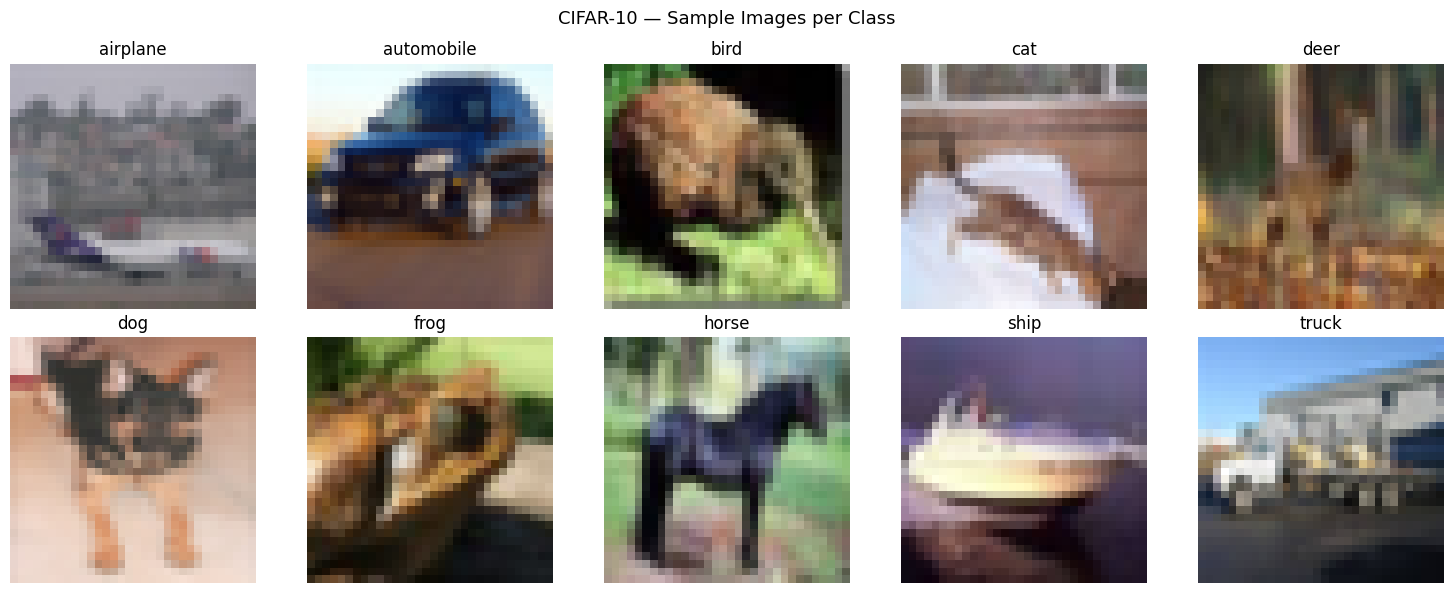

In [ ]:
print(f"Train images : {X_train_c.shape}")
print(f"Test images  : {X_test_c.shape}")
print(f"Image shape  : {X_train_c.shape[1:]}")

print("\nImages per class (train):")
for cls, cnt in zip(*np.unique(y_train_c, return_counts=True)):
    print(f"  {cls} ({class_names[cls]}): {cnt}")

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.ravel()):
    idx = np.where(y_train_c.ravel() == i)[0][0]
    ax.imshow(X_train_c[idx]); ax.set_title(class_names[i]); ax.axis('off')
plt.suptitle("CIFAR-10 — Sample Images per Class", fontsize=13)
plt.tight_layout(); plt.show()

## Task 2: Preprocessing
> Normalize pixel values to $[0, 1]$ and flatten images into 1-D feature vectors

In [ ]:
X_all_c    = np.concatenate([X_train_c, X_test_c], axis=0)
X_all_norm = X_all_c.astype('float32') / 255.0
X_flat     = X_all_norm.reshape(X_all_norm.shape[0], -1)

print(f"Original shape  : {X_all_c.shape}")
print(f"Flattened shape : {X_flat.shape}  ({32}×{32}×{3} = {32*32*3} features)")
print(f"Pixel range     : [{X_flat.min():.2f}, {X_flat.max():.2f}]")

Original shape  : (60000, 32, 32, 3)
Flattened shape : (60000, 3072)  (32×32×3 = 3072 features)
Pixel range     : [0.00, 1.00]


## Task 3: Apply K-Means Clustering
> Run K-Means with $k = 10$ — report final inertia and discuss its significance

In [ ]:
# Sub-sample to keep runtime manageable (10 000 images)
N_SAMPLE = 10_000
rng      = np.random.default_rng(RANDOM_STATE)
idx_s    = rng.choice(len(X_flat), N_SAMPLE, replace=False)
X_sample = X_flat[idx_s]

kmeans = KMeans(n_clusters=10, random_state=RANDOM_STATE, n_init=10, max_iter=300)
kmeans.fit(X_sample)

print(f"K-Means (k=10) — Final Inertia : {kmeans.inertia_:,.2f}")
print("\nInertia = sum of squared distances from each point to its centroid.")
print("Lower inertia = tighter clusters; however, pixel-based centroids may not")
print("align with semantic categories (see Task 5).\n")

labels, counts = np.unique(kmeans.labels_, return_counts=True)
print("Cluster sizes:")
for l, c in zip(labels, counts):
    print(f"  Cluster {l:2d}: {c} samples")

K-Means (k=10) — Final Inertia : 1,211,801.25

Inertia = sum of squared distances from each point to its centroid.
Lower inertia = tighter clusters; however, pixel-based centroids may not
align with semantic categories (see Task 5).

Cluster sizes:
  Cluster  0: 990 samples
  Cluster  1: 1052 samples
  Cluster  2: 980 samples
  Cluster  3: 1055 samples
  Cluster  4: 1082 samples
  Cluster  5: 644 samples
  Cluster  6: 819 samples
  Cluster  7: 778 samples
  Cluster  8: 993 samples
  Cluster  9: 1607 samples


## Task 4: Visualize Cluster Centroids
> Reshape centroids to image format ($32 \times 32 \times 3$) and label each with its cluster index

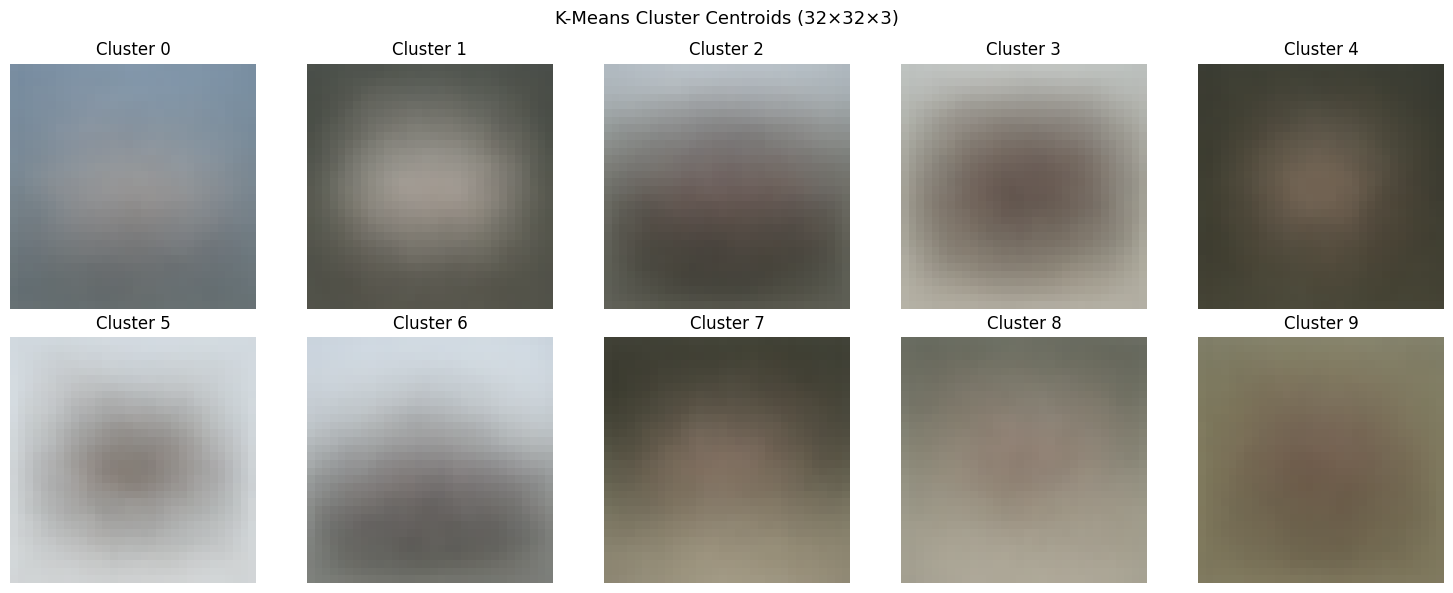

In [ ]:
centroids = kmeans.cluster_centers_   # shape (10, 3072)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.ravel()):
    img = np.clip(centroids[i].reshape(32, 32, 3), 0, 1)
    ax.imshow(img); ax.set_title(f'Cluster {i}'); ax.axis('off')

plt.suptitle("K-Means Cluster Centroids (32×32×3)", fontsize=13)
plt.tight_layout(); plt.show()

## Task 5: Analysis and Discussion
> Discuss the limitations of K-Means on CIFAR-10 — explain why pixel-based features may not capture semantic structure — suggest improvements

---
# Part 4: Classification and Model Comparison
> **Dataset:** `heart.csv` — 5 points total

| Criteria | Marks |
| :--- | :---: |
| Logistic Regression (From Scratch) | 2 |
| KNN and SVM Implementation | 1 |
| Evaluation Metrics | 1 |
| Report Quality | 1 |

## 0. Data Loading and EDA

In [ ]:
df_heart = pd.read_csv('heart.csv')
print("Shape:", df_heart.shape)
display(df_heart.head())
display(df_heart.describe().round(4))

print(f"\nMissing values: {df_heart.isnull().sum().sum()}")
print("\nTarget distribution:")
display(df_heart['target'].value_counts().rename({1: 'Heart Disease', 0: 'No Disease'}))

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

df_heart['target'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','tomato'], rot=0)
axes[0].set_title('Target Distribution'); axes[0].set_xlabel('Heart Disease (1=Yes)')

sns.heatmap(df_heart.corr(), ax=axes[1], cmap='coolwarm', center=0,
            linewidths=0.3, annot=False)
axes[1].set_title('Correlation Heatmap')

for label, grp in df_heart.groupby('target'):
    axes[2].hist(grp['age'], bins=20, alpha=0.6,
                 label='Disease' if label else 'No Disease')
axes[2].set_title('Age Distribution by Target'); axes[2].legend()

plt.tight_layout(); plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'heart.csv'

## 1. Feature Engineering

#### 1a. Feature Combinations and Transformations

In [ ]:
df_fe = df_heart.copy()

df_fe['age_x_chol']     = df_fe['age']     * df_fe['chol']
df_fe['age_x_thalach']  = df_fe['age']     * df_fe['thalach']
df_fe['bp_x_chol']      = df_fe['trestbps']* df_fe['chol']
df_fe['age_x_oldpeak']  = df_fe['age']     * df_fe['oldpeak']
df_fe['thalach_oldpeak']= df_fe['thalach'] * df_fe['oldpeak']

print("Interaction features added:")
display(df_fe[['age_x_chol','age_x_thalach','bp_x_chol',
               'age_x_oldpeak','thalach_oldpeak']].describe().round(4))

#### 1b. Logarithmic, Square Root, and Polynomial Transformations on Continuous Variables

In [ ]:
continuous = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

for col in continuous:
    df_fe[f'log_{col}']  = np.log1p(df_fe[col].clip(lower=0))
    df_fe[f'sqrt_{col}'] = np.sqrt(df_fe[col].clip(lower=0))
    df_fe[f'sq_{col}']   = df_fe[col] ** 2

print(f"Added {3 * len(continuous)} transformation features.")
print(f"Total columns (incl. target): {df_fe.shape[1]}")
display(df_fe.head(2))

#### 1c. Impact Evaluation — EDA and Validation Metrics

In [ ]:
from sklearn.linear_model import LogisticRegression as LR_sklearn

X_orig = df_heart.drop(columns=['target']).values
X_eng  = df_fe.drop(columns=['target']).values
y_hrt  = df_heart['target'].values

sc_orig = StandardScaler(); sc_eng = StandardScaler()

orig_cv = cross_val_score(LR_sklearn(max_iter=1000),
                          sc_orig.fit_transform(X_orig), y_hrt, cv=5).mean()
eng_cv  = cross_val_score(LR_sklearn(max_iter=1000),
                          sc_eng.fit_transform(X_eng),  y_hrt, cv=5).mean()

print(f"LR CV Accuracy — Original features  : {orig_cv:.4f}")
print(f"LR CV Accuracy — Engineered features : {eng_cv:.4f}")

# F-score ranking of engineered features
f_scores, _ = f_classif(sc_eng.transform(X_eng), y_hrt)
feat_rank = (pd.DataFrame({'Feature': df_fe.drop(columns=['target']).columns,
                           'F-score': f_scores.round(3)})
             .sort_values('F-score', ascending=False))
print("\nTop 10 features by F-score:")
display(feat_rank.head(10))

## 2. Model Implementation

### 2a. Logistic Regression — From Scratch
> Implement: sigmoid function, loss function (with/without regularization), gradient descent, L1/L2 regularization, prediction and evaluation

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
\qquad
\mathcal{L} = -\frac{1}{n}\sum_{i=1}^{n}\left[y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)\right]
$$

In [ ]:
class LogisticRegressionScratch:
    def __init__(self, lr=0.1, n_iter=500, regularization=None, C=1.0):
        self.lr = lr; self.n_iter = n_iter
        self.regularization = regularization; self.C = C
        self.losses_ = []

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -250, 250)))

    def _loss(self, y, y_hat):
        eps = 1e-9
        bce = -np.mean(y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps))
        if self.regularization == 'l2':
            return bce + (1 / (2 * self.C)) * np.sum(self.w_ ** 2)
        if self.regularization == 'l1':
            return bce + (1 / self.C) * np.sum(np.abs(self.w_))
        return bce

    def fit(self, X, y):
        n, p = X.shape
        self.w_ = np.zeros(p); self.b_ = 0.0
        for _ in range(self.n_iter):
            y_hat = self._sigmoid(X @ self.w_ + self.b_)
            err   = y_hat - y
            dw    = (X.T @ err) / n
            if self.regularization == 'l2': dw += self.w_ / self.C
            elif self.regularization == 'l1': dw += np.sign(self.w_) / self.C
            self.w_ -= self.lr * dw
            self.b_ -= self.lr * err.mean()
            self.losses_.append(self._loss(y, y_hat))
        return self

    def predict_proba(self, X):
        return self._sigmoid(X @ self.w_ + self.b_)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)


# Prepare data — use original features
sc_lr  = StandardScaler()
X_sc   = sc_lr.fit_transform(X_orig)
X_lr_tr, X_lr_te, y_lr_tr, y_lr_te = train_test_split(
    X_sc, y_hrt, test_size=0.2, random_state=RANDOM_STATE)

lr_scratch = LogisticRegressionScratch(lr=0.1, n_iter=500, regularization='l2', C=1.0)
lr_scratch.fit(X_lr_tr, y_lr_tr)

plt.figure(figsize=(8, 4))
plt.plot(lr_scratch.losses_)
plt.title('Logistic Regression (Scratch) — Training Loss Curve')
plt.xlabel('Iteration'); plt.ylabel('Loss'); plt.show()
print("Training complete.")

### 2b. k-Nearest Neighbors (KNN)
> Experiment with different $k$ values and distance metrics (Euclidean and Manhattan)

In [ ]:
k_range = range(1, 21)
knn_eu, knn_ma = [], []

for k in k_range:
    knn_eu.append(cross_val_score(KNeighborsClassifier(k, metric='euclidean'),
                                  X_sc, y_hrt, cv=5).mean())
    knn_ma.append(cross_val_score(KNeighborsClassifier(k, metric='manhattan'),
                                  X_sc, y_hrt, cv=5).mean())

best_k_eu = list(k_range)[np.argmax(knn_eu)]
best_k_ma = list(k_range)[np.argmax(knn_ma)]
print(f"Best k (Euclidean) : {best_k_eu}  | CV Acc: {max(knn_eu):.4f}")
print(f"Best k (Manhattan) : {best_k_ma}  | CV Acc: {max(knn_ma):.4f}")

plt.figure(figsize=(10, 5))
plt.plot(k_range, knn_eu, marker='o', label='Euclidean')
plt.plot(k_range, knn_ma, marker='s', label='Manhattan')
plt.xlabel('k'); plt.ylabel('CV Accuracy')
plt.title('KNN — Accuracy vs. k by Distance Metric')
plt.legend(); plt.show()

knn_best = KNeighborsClassifier(n_neighbors=best_k_eu, metric='euclidean')
knn_best.fit(X_lr_tr, y_lr_tr)

### 2c. Support Vector Machines (SVM)
> Experiment with different kernels (linear, polynomial, RBF) and tune hyperparameter $C$

In [ ]:
svm_results = []
for kernel in ['linear', 'poly', 'rbf']:
    for C in [0.1, 1.0, 10.0]:
        score = cross_val_score(SVC(kernel=kernel, C=C, random_state=RANDOM_STATE),
                                X_sc, y_hrt, cv=5).mean()
        svm_results.append({'Kernel': kernel, 'C': C, 'CV_Accuracy': round(score, 4)})

df_svm = pd.DataFrame(svm_results).sort_values('CV_Accuracy', ascending=False)
display(df_svm)

best_svm_row = df_svm.iloc[0]
svm_best = SVC(kernel=best_svm_row['Kernel'], C=best_svm_row['C'],
               probability=True, random_state=RANDOM_STATE)
svm_best.fit(X_lr_tr, y_lr_tr)
print(f"\nBest SVM: kernel={best_svm_row['Kernel']}, C={best_svm_row['C']}")

## 3. Evaluation Metrics
> For all models — Accuracy, Precision, Recall, F1-Score, ROC-AUC, and Confusion Matrix
> For Logistic Regression: compute manually

$$
\text{Precision} = \frac{TP}{TP+FP}
\qquad
\text{Recall} = \frac{TP}{TP+FN}
\qquad
F_1 = 2 \cdot \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
$$

In [ ]:
def metrics_manual(y_true, y_pred, y_prob=None, label='Model'):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    acc  = (TP + TN) / len(y_true)
    prec = TP / (TP + FP) if TP + FP else 0
    rec  = TP / (TP + FN) if TP + FN else 0
    f1   = 2 * prec * rec / (prec + rec) if prec + rec else 0
    auc  = roc_auc_score(y_true, y_prob) if y_prob is not None else None
    cm   = np.array([[TN, FP], [FN, TP]])
    return {'Model': label,
            'Accuracy': round(acc, 4), 'Precision': round(prec, 4),
            'Recall':   round(rec, 4), 'F1-Score':  round(f1, 4),
            'ROC-AUC':  round(auc, 4) if auc else 'N/A',
            '_cm': cm}

lr_pred  = lr_scratch.predict(X_lr_te)
lr_prob  = lr_scratch.predict_proba(X_lr_te)
knn_pred = knn_best.predict(X_lr_te)
svm_pred = svm_best.predict(X_lr_te)
svm_prob = svm_best.predict_proba(X_lr_te)[:, 1]

results_p4 = [
    metrics_manual(y_lr_te, lr_pred,  lr_prob,  'LR (Scratch)'),
    metrics_manual(y_lr_te, knn_pred, None,      'KNN'),
    metrics_manual(y_lr_te, svm_pred, svm_prob,  'SVM'),
]

summary = pd.DataFrame([{k: v for k, v in r.items() if k != '_cm'} for r in results_p4])
display(summary)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, res in zip(axes, results_p4):
    sns.heatmap(res['_cm'], annot=True, fmt='d', ax=ax, cmap='Blues',
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['True 0', 'True 1'])
    ax.set_title(f"Confusion Matrix — {res['Model']}")
plt.tight_layout(); plt.show()

## 4. Cross-Validation
> Implement $k$-fold cross-validation for all models — compare average performance metrics across folds to assess consistency

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_models = {
    'LR (sklearn)': LR_sklearn(max_iter=1000),
    'KNN':          KNeighborsClassifier(n_neighbors=best_k_eu),
    'SVM':          SVC(kernel=best_svm_row['Kernel'],
                        C=best_svm_row['C'], random_state=RANDOM_STATE),
}

cv_rows = []
for name, model in cv_models.items():
    for metric in ['accuracy', 'precision', 'recall', 'f1']:
        scores = cross_val_score(model, X_sc, y_hrt, cv=kf, scoring=metric)
        cv_rows.append({'Model': name, 'Metric': metric.capitalize(),
                        'Mean': round(scores.mean(), 4),
                        'Std':  round(scores.std(),  4)})

df_cv = pd.DataFrame(cv_rows)
display(df_cv.pivot_table(index='Model', columns='Metric', values=['Mean', 'Std']))